# Baseline : TF-IDF + Logistic Regression
Référence de performance. Tout modèle Deep Learning doit dépasser cette baseline.

**Imports & Configuration**

In [1]:
import json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)
import joblib

SEED    = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path('data/processed')
RES_DIR  = Path('results')
RES_DIR.mkdir(exist_ok=True)
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

LABEL_TO_NAME = {0: 'négatif', 1: 'neutre', 2: 'positif'}


**Chargement des données**

In [2]:
df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_val   = pd.read_csv(DATA_DIR / 'val.csv')
df_test  = pd.read_csv(DATA_DIR / 'test.csv')

X_train, y_train = df_train['Tweet_clean'].astype(str), df_train['label']
X_val,   y_val   = df_val['Tweet_clean'].astype(str),   df_val['label']
X_test,  y_test  = df_test['Tweet_clean'].astype(str),  df_test['label']


**Architecture — TF-IDF + Logistic Regression**

***Justification :***
- TF-IDF bigrammes capture les collocation ('not good', 'strong buy')
- `min_df=2` : ignore les tokens très rares (bruit)
- `class_weight='balanced'` : compense le déséquilibre naturellement
- `max_iter=1000` : assure la convergence avec C=1 par défaut

***Pipeline de la baseline***

tweets  
&nbsp;&nbsp;&nbsp;&nbsp;↓  
TF-IDF  
&nbsp;&nbsp;&nbsp;&nbsp;↓  
vecteurs de nombres  
&nbsp;&nbsp;&nbsp;&nbsp;↓  
Logistic Regression  
&nbsp;&nbsp;&nbsp;&nbsp;↓  
sentiment

In [3]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), # Pour récupérer une association de deux mot dans le dictionnaire. Ex : "not good"
        min_df=2, #Retire les mots rencontré qu'une seul fois.
        max_features= 30000, #On considère les 30000 les mots les plus utilisés. Assez large.
        sublinear_tf=True,         # TF log-normalisé
        strip_accents='unicode',
        analyzer='word',
        token_pattern=r'\w+',
    )),
    ('clf', LogisticRegression(
        class_weight='balanced', # Pour gérer les classes désequilibrées ( cf. 4_preprocessing.ipynb)
        max_iter=1000,
        C=1.0,                     # régularisation L2 par défaut
        multi_class='multinomial', #Classification multi-classe
        solver='lbfgs',
        random_state=SEED
    ))
])

pipeline.fit(X_train, y_train)
print('Entraînement terminé')

d:\M2_MoSEF\NLP_Project\NLP_Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Entraînement terminé


**Evaluation**


=== Val ===
Accuracy  : 0.7084
F1-macro  : 0.6999
ROC-AUC   : 0.8699
F1 négatif : 0.6505 | F1 neutre : 0.7179 | F1 positif : 0.7313

              precision    recall  f1-score   support

     négatif       0.58      0.74      0.65      1197
      neutre       0.76      0.68      0.72      2770
     positif       0.74      0.73      0.73      2371

    accuracy                           0.71      6338
   macro avg       0.69      0.72      0.70      6338
weighted avg       0.72      0.71      0.71      6338



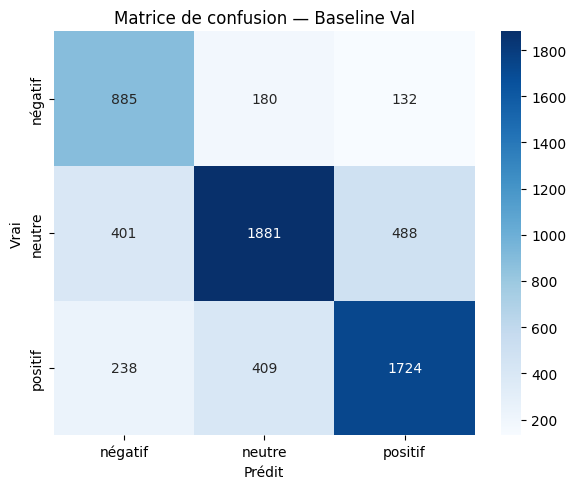


=== Test ===
Accuracy  : 0.7083
F1-macro  : 0.6993
ROC-AUC   : 0.8717
F1 négatif : 0.6461 | F1 neutre : 0.7126 | F1 positif : 0.7392

              precision    recall  f1-score   support

     négatif       0.58      0.74      0.65      1197
      neutre       0.76      0.67      0.71      2771
     positif       0.74      0.74      0.74      2370

    accuracy                           0.71      6338
   macro avg       0.69      0.72      0.70      6338
weighted avg       0.72      0.71      0.71      6338



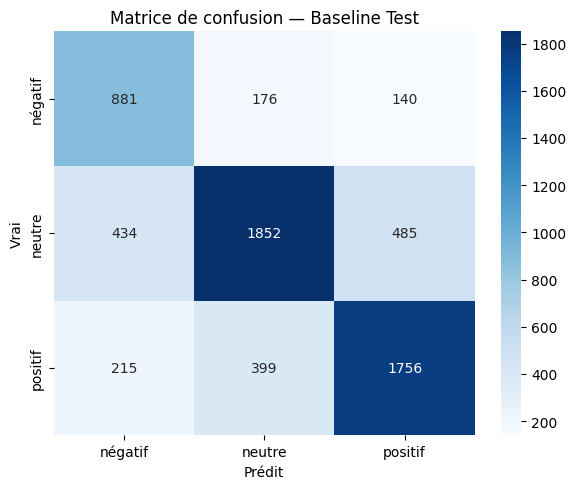

In [4]:
def evaluate(model, X, y_true, split_name='Test'):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)

    acc     = accuracy_score(y_true, y_pred)
    f1_mac  = f1_score(y_true, y_pred, average='macro')
    f1_per  = f1_score(y_true, y_pred, average=None)
    auc     = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')

    print(f'\n=== {split_name} ===')
    print(f'Accuracy  : {acc:.4f}')
    print(f'F1-macro  : {f1_mac:.4f}')
    print(f'ROC-AUC   : {auc:.4f}')
    print(f'F1 négatif : {f1_per[0]:.4f} | F1 neutre : {f1_per[1]:.4f} | F1 positif : {f1_per[2]:.4f}')
    print('\n' + classification_report(y_true, y_pred,
          target_names=[LABEL_TO_NAME[i] for i in [0,1,2]]))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[LABEL_TO_NAME[i] for i in [0,1,2]],
                yticklabels=[LABEL_TO_NAME[i] for i in [0,1,2]])
    plt.title(f'Matrice de confusion — Baseline {split_name}')
    plt.ylabel('Vrai'); plt.xlabel('Prédit')
    plt.tight_layout()
    plt.savefig(RES_DIR / f'confusion_baseline_{split_name.lower()}.png', dpi=150)
    plt.show()

    return {'accuracy': acc, 'f1_macro': f1_mac, 'roc_auc': auc,
            'f1_negatif': f1_per[0], 'f1_neutre': f1_per[1], 'f1_positif': f1_per[2]}

metrics_val  = evaluate(pipeline, X_val,  y_val,  'Val')
metrics_test = evaluate(pipeline, X_test, y_test, 'Test')

**Analyse des features importantes**

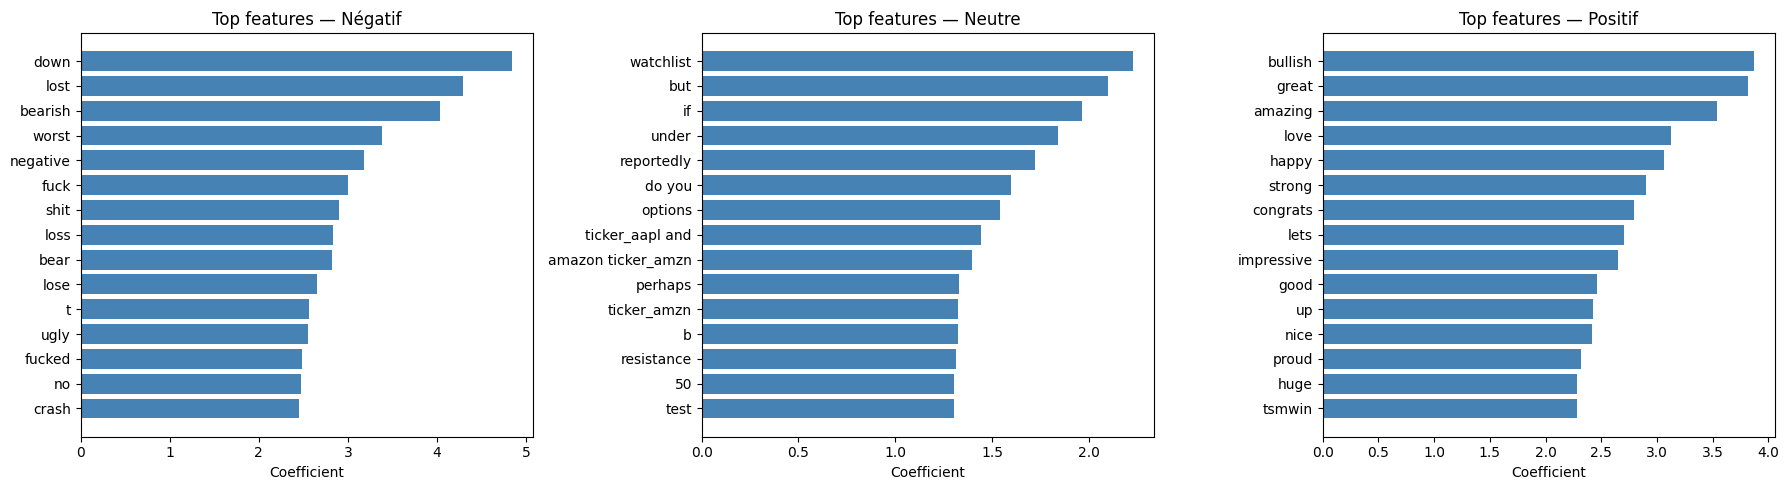

In [5]:
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coef          = pipeline.named_steps['clf'].coef_   # shape (3, n_features)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (ax, name) in enumerate(zip(axes, ['Négatif', 'Neutre', 'Positif'])):
    top_idx = np.argsort(coef[i])[-15:][::-1]
    ax.barh(feature_names[top_idx][::-1], coef[i][top_idx][::-1], color='steelblue')
    ax.set_title(f'Top features — {name}')
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig(RES_DIR / 'baseline_top_features.png', dpi=150)
plt.show()

**Intrprétation**

La baseline atteint ~71% d’accuracy, ce qui sert de plancher de performance. Elle montre que les mots clés simples permettent déjà de capturer la majorité des sentiments.
Cependant, les performances plus faibles sur la classe négative montrent que des modèles plus avancés (BERT/FinBERT, architectures hybrides) peuvent exploiter le contexte et la structure du langage pour améliorer la détection des sentiments subtils.


**Sauvegarde**

In [6]:
joblib.dump(pipeline, MODELS_DIR / 'baseline_tfidf_logreg.joblib')

with open(RES_DIR / 'metrics_baseline.json', 'w') as f:
    json.dump({'model': 'TF-IDF + LogReg', 'val': metrics_val, 'test': metrics_test}, f, indent=2)


print(f'\nRéférence à battre — F1-macro test : {metrics_test["f1_macro"]:.4f}')


Référence à battre — F1-macro test : 0.6993
